
=== CartPole seed 0 ===
1024 steps: 104.5 +/- 47.4
2048 steps: 132.7 +/- 47.0
3072 steps: 121.0 +/- 34.2
4096 steps: 112.8 +/- 37.2
5120 steps: 93.8 +/- 31.4
6144 steps: 104.1 +/- 26.9
7168 steps: 120.6 +/- 44.4
8192 steps: 140.2 +/- 55.4
9216 steps: 149.1 +/- 48.7
10240 steps: 185.5 +/- 73.3
11264 steps: 223.9 +/- 87.6
12288 steps: 216.2 +/- 53.9
13312 steps: 297.5 +/- 109.9
14336 steps: 282.5 +/- 90.2
>>> π₂ saved at 14336 steps: 282.5 +/- 90.2
15360 steps: 500.0 +/- 0.0
>>> π₁ saved at 15360 steps: 500.0 +/- 0.0
Both policies saved for seed 0, stopping


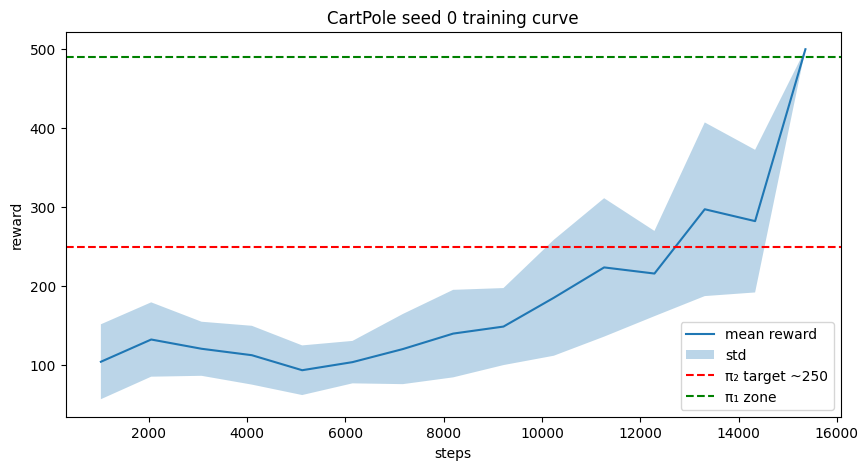


=== CartPole seed 3 ===
1024 steps: 105.0 +/- 48.6
2048 steps: 84.3 +/- 44.1
3072 steps: 72.6 +/- 21.4
4096 steps: 106.9 +/- 52.5
5120 steps: 124.3 +/- 67.4
6144 steps: 144.6 +/- 69.1
7168 steps: 142.4 +/- 74.8
8192 steps: 158.0 +/- 100.8
9216 steps: 161.3 +/- 88.8
10240 steps: 175.5 +/- 98.3
11264 steps: 146.1 +/- 93.8
12288 steps: 148.1 +/- 84.3
13312 steps: 157.2 +/- 75.6
14336 steps: 199.4 +/- 78.3
15360 steps: 286.5 +/- 112.3
16384 steps: 335.0 +/- 111.1
>>> π₂ saved at 16384 steps: 335.0 +/- 111.1
17408 steps: 404.6 +/- 112.2
18432 steps: 322.5 +/- 105.4
19456 steps: 354.9 +/- 134.1
20480 steps: 359.8 +/- 118.3
21504 steps: 402.9 +/- 99.3
22528 steps: 494.0 +/- 22.8
>>> π₁ saved at 22528 steps: 494.0 +/- 22.8
Both policies saved for seed 3, stopping


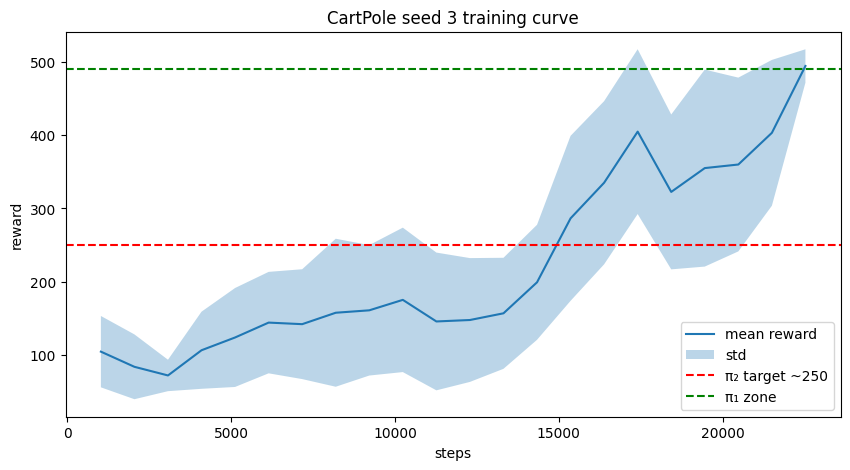


=== CartPole seed 4 ===
1024 steps: 88.9 +/- 30.6
2048 steps: 105.0 +/- 43.0
3072 steps: 99.9 +/- 50.8
4096 steps: 92.8 +/- 39.4
5120 steps: 83.4 +/- 28.9
6144 steps: 90.7 +/- 38.9
7168 steps: 126.3 +/- 48.4
8192 steps: 142.1 +/- 58.9
9216 steps: 144.4 +/- 60.9
10240 steps: 148.6 +/- 66.6
11264 steps: 175.6 +/- 62.1
12288 steps: 215.5 +/- 70.8
13312 steps: 264.6 +/- 77.3
14336 steps: 353.5 +/- 80.4
15360 steps: 403.6 +/- 77.8
>>> π₂ saved at 15360 steps: 403.6 +/- 77.8
16384 steps: 493.6 +/- 21.1
>>> π₁ saved at 16384 steps: 493.6 +/- 21.1
Both policies saved for seed 4, stopping


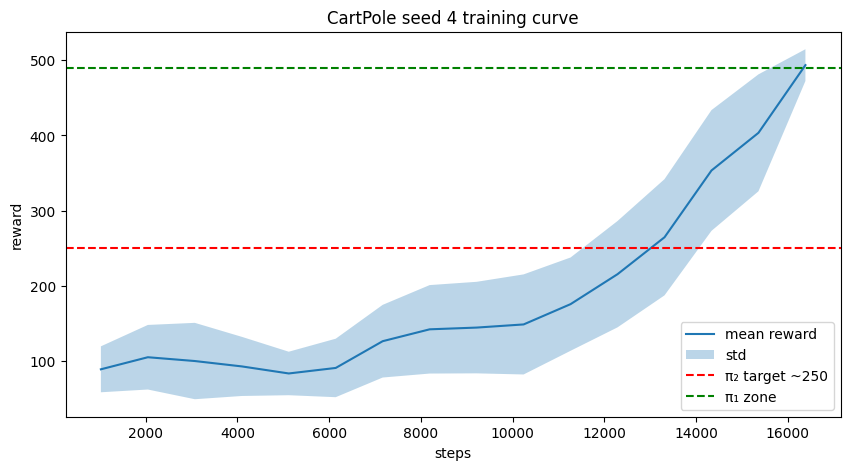


Done! Saved policies:
  pi1_cartpole_seed0.zip
  pi2_cartpole_seed0.zip
  pi1_cartpole_seed3.zip
  pi2_cartpole_seed3.zip
  pi1_cartpole_seed4.zip
  pi2_cartpole_seed4.zip


In [3]:
import os
import gymnasium as gym
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

save_path = "outputs/checkpoints"
os.makedirs(save_path, exist_ok=True)

# CartPole π₂ targets: seed0@14336, seed3@16384, seed4@15360
pi2_targets = {
    0: 14336,
    3: 16384,
    4: 15360,
}

checkpoint_interval = 1024

for seed, pi2_steps in pi2_targets.items():
    print(f"\n=== CartPole seed {seed} ===")
    
    env_train = gym.make("CartPole-v1")
    env_eval  = gym.make("CartPole-v1")
    
    steps_log, mean_log, std_log = [], [], []
    
    model = PPO(
        "MlpPolicy",
        env_train,
        verbose=0,
        device="cpu",
        seed=seed,
        learning_rate=1e-4,
        n_steps=256,
        batch_size=64,
        n_epochs=5,
        ent_coef=0.01,
        gamma=0.99,
    )
    
    total_steps = 0
    pi2_saved = False
    pi1_saved = False

    for _ in range(0, 100_000, checkpoint_interval):
        model.learn(
            total_timesteps=checkpoint_interval,
            reset_num_timesteps=False
        )
        total_steps += checkpoint_interval
        mean_reward, std_reward = evaluate_policy(
            model, env_eval, n_eval_episodes=100, deterministic=True
        )
        steps_log.append(total_steps)
        mean_log.append(mean_reward)
        std_log.append(std_reward)
        print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

        # save π₂ at target steps
        if total_steps == pi2_steps and not pi2_saved:
            model.save(os.path.join(save_path, f"pi2_cartpole_seed{seed}"))
            print(f">>> π₂ saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
            pi2_saved = True

        # save π₁ once policy is excellent
        if mean_reward >= 490 and not pi1_saved:
            model.save(os.path.join(save_path, f"pi1_cartpole_seed{seed}"))
            print(f">>> π₁ saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
            pi1_saved = True

        if pi1_saved:
            print(f"Both policies saved for seed {seed}, stopping")
            break

    # plot
    plt.figure(figsize=(10, 5))
    plt.plot(steps_log, mean_log, label="mean reward")
    plt.fill_between(
        steps_log,
        [m - s for m, s in zip(mean_log, std_log)],
        [m + s for m, s in zip(mean_log, std_log)],
        alpha=0.3, label="std"
    )
    plt.axhline(250, color="red",   linestyle="--", label="π₂ target ~250")
    plt.axhline(490, color="green", linestyle="--", label="π₁ zone")
    plt.xlabel("steps")
    plt.ylabel("reward")
    plt.title(f"CartPole seed {seed} training curve")
    plt.legend()
    plt.show()

print("\nDone! Saved policies:")
for seed in pi2_targets:
    print(f"  pi1_cartpole_seed{seed}.zip")
    print(f"  pi2_cartpole_seed{seed}.zip")

In [6]:
# Pendulum π₂ targets: seed0@160768, seed1@157696, seed2@161792
pendulum_pi2_targets = {
    0: 160768,
    1: 157696,
    2: 161792,
}

for seed, pi2_steps in pendulum_pi2_targets.items():
    print(f"\n=== Pendulum seed {seed} ===")
    env_train = gym.make("Pendulum-v1")
    env_eval  = gym.make("Pendulum-v1")

    model = PPO(
        "MlpPolicy", env_train, verbose=0, device="cpu", seed=seed,
        learning_rate=3e-4, n_steps=2048, batch_size=64,
        n_epochs=5, ent_coef=0.01, gamma=0.99,
    )
    total_steps = 0
    pi2_saved = False
    pi1_saved = False

    while not pi1_saved:
        model.learn(total_timesteps=checkpoint_interval, reset_num_timesteps=False)
        total_steps += checkpoint_interval

        eval_interval = 5_000 if pi2_saved else 10_000
        if total_steps == pi2_steps or total_steps % eval_interval == 0:
            mean_reward, std_reward = evaluate_policy(
                model, env_eval, n_eval_episodes=100, deterministic=True
            )
            print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

            if total_steps == pi2_steps and not pi2_saved:
                model.save(os.path.join(save_path, f"pi2_pendulum_seed{seed}"))
                print(f">>> π₂ saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
                pi2_saved = True

            if mean_reward >= -250 and not pi1_saved:
                model.save(os.path.join(save_path, f"pi1_pendulum_seed{seed}"))
                print(f">>> π₁ saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
                pi1_saved = True
                print(f"Both policies saved for seed {seed}, stopping")

print("\nDone! Saved policies:")
for seed in pendulum_pi2_targets:
    print(f"  pi1_pendulum_seed{seed}.zip  |  pi2_pendulum_seed{seed}.zip")


=== Pendulum seed 0 ===
160768 steps: -816.1 +/- 259.8
>>> π₂ saved at 160768 steps: -816.1 +/- 259.8
640000 steps: -142.8 +/- 85.2
>>> π₁ saved at 640000 steps: -142.8 +/- 85.2
Both policies saved for seed 0, stopping

=== Pendulum seed 1 ===
157696 steps: -880.8 +/- 143.2
>>> π₂ saved at 157696 steps: -880.8 +/- 143.2
640000 steps: -147.4 +/- 90.5
>>> π₁ saved at 640000 steps: -147.4 +/- 90.5
Both policies saved for seed 1, stopping

=== Pendulum seed 2 ===
161792 steps: -862.9 +/- 182.3
>>> π₂ saved at 161792 steps: -862.9 +/- 182.3
640000 steps: -154.2 +/- 82.4
>>> π₁ saved at 640000 steps: -154.2 +/- 82.4
Both policies saved for seed 2, stopping

Done! Saved policies:
  pi1_pendulum_seed0.zip  |  pi2_pendulum_seed0.zip
  pi1_pendulum_seed1.zip  |  pi2_pendulum_seed1.zip
  pi1_pendulum_seed2.zip  |  pi2_pendulum_seed2.zip
